# Deep SRQ Network Architecture Ablation (Serial + PATH Pool)

Compares DeepSRQ critic architectures while holding the training loop and SRE solve configuration fixed.

- Serial rollout
- PATH pool solver with 8 workers
- Pure starts plus 5 random restarts
- 2 training runs per architecture: one on Scenario 1 and one on Scenario 3
- Scenarios 1 and 3
- Robust epsilon starts at 0.5 and follows a linear schedule

The three architecture variants are joint Q output, independent per-agent Q networks, and shared trunk with separate per-agent heads.

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
if ROOT.name == "bimatrix_game":
    BIMATRIX_DIR = ROOT
else:
    BIMATRIX_DIR = ROOT / "discrete_action_space" / "bimatrix_game"
DISCRETE_DIR = BIMATRIX_DIR.parent
for path in (BIMATRIX_DIR, DISCRETE_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

MPLCONFIGDIR = Path("/tmp") / "sre_dqn_matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

from experiment_harness import (
    BASE_SEED,
    configure_path_runtime,
    run_deep_srq_ablation_variants,
    summarize_ablation_timing_rows,
)
from stats_utils import save_training_stats


In [2]:
PATHWRAP = str(configure_path_runtime(DISCRETE_DIR))
OUTPUT_ROOT = BIMATRIX_DIR / "ablation_runs" / "network_architecture"

SCENARIOS = ("scenario1", "scenario3")
N_EPISODES = 3000
ROBUST_EPSILON_START = 0.5
EPSILON_SCHEDULE = "linear"
USE_GPU = True
SOLVER_NAME = "path_c_pool"

BASE_HP = {
    "sre_solver_workers": 8,
    "sre_num_repeats": 5,
    "sre_include_pure_starts": True,
}

BASE_RUN_VARIANTS = (
    {
        "label": "joint_output",
        "network_type": "joint_output",
        "display_name": "Joint Q network",
    },
    {
        "label": "per_agent_independent",
        "network_type": "per_agent_independent",
        "display_name": "Independent Q networks",
    },
    {
        "label": "shared_trunk_separate_heads",
        "network_type": "shared_trunk_separate_heads",
        "display_name": "Shared trunk, separate heads",
    },
)

RUN_VARIANTS = tuple(
    {
        "label": variant["label"],
        "base_label": variant["label"],
        "display_name": variant["display_name"],
        "run_name_suffix": variant["label"],
        "hyperparameter_overrides": {"network_type": variant["network_type"]},
    }
    for variant in BASE_RUN_VARIANTS
)

VARIANT_METADATA = {variant["label"]: variant for variant in RUN_VARIANTS}
BASE_VARIANT_ORDER = {
    variant["label"]: index for index, variant in enumerate(BASE_RUN_VARIANTS)
}
CASE_LABELS = {
    variant["label"]: variant["display_name"] for variant in BASE_RUN_VARIANTS
}


In [3]:
results = run_deep_srq_ablation_variants(
    variants=RUN_VARIANTS,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED,
    pathwrap_path=PATHWRAP,
    output_root=OUTPUT_ROOT,
    use_gpu=USE_GPU,
    write_plots=False,
    default_n_episodes=N_EPISODES,
    default_epsilon_robust_initial=ROBUST_EPSILON_START,
    default_epsilon_schedule=EPSILON_SCHEDULE,
    default_solver_name=SOLVER_NAME,
    default_hyperparameter_overrides=BASE_HP,
)

save_training_stats(OUTPUT_ROOT / "network_architecture_manifest.txt", results)


Deep SRQ Scenario 1 | DeepSRQ vs DeepSRQ | eps0=0.5 | schedule=linear | solver=path_c_pool | seed=2025


scenario1:eps0.5_linear__joint_output:path_c_pool: 100%|██████████| 3000/3000 [18:56<00:00,  2.64it/s] 

Saved stats to /home/wowthecoder/SRE-DQN/discrete_action_space/bimatrix_game/ablation_runs/network_architecture/joint_output/scenario1/deepsrq_vs_deepsrq__eps0.5_linear__joint_output/training_stats.txt
Scenario 1 - DeepSRQ vs DeepSRQ - eps0.5_linear__joint_output
Wall clock: 1211.202s (20.19 min)
Episode time:   count=3000, mean=0.402941s (402940.98 us), min=0.000649s, max=5.589965s, std=0.259438s
SRE solve time: count=177616, mean=0.005768s (5768.49 us), min=0.001434s, max=0.145185s, std=0.005543s
Backend solve:  count=177616, mean=0.014132s (14132.00 us), min=0.007352s, max=0.171388s, std=0.006028s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=177616, mean=0.005768s (5768.49 us), min=0.001434s, max=0.145185s, std=0.005543s
    Backend:    count=177616, mean=0.014132s (14132.00 us), min=0.007352s, max=0.171388s, std=0.006028s
    Update:     count=10943, mean=0.040718s (40717.62 us), min=0.018342s, max=1.219548s, std=0.016179s

Reward Summary
Scenario   | Pair            

Deep SRQ Scenario 1 | DeepSRQ vs DeepSRQ | eps0=0.5 | schedule=linear | solver=path_c_pool | seed=2026


scenario1:eps0.5_linear__per_agent_independent:path_c_pool: 100%|██████████| 3000/3000 [17:34<00:00,  2.85it/s] 

...

Saved stats to /home/wowthecoder/SRE-DQN/discrete_action_space/bimatrix_game/ablation_runs/network_architecture/per_agent_independent/scenario3/deepsrq_vs_deepsrq__eps0.5_linear__per_agent_independent/training_stats.txt
Scenario 3 - DeepSRQ vs DeepSRQ - eps0.5_linear__per_agent_independent
Wall clock: 1644.138s (27.40 min)
Episode time:   count=3000, mean=0.547186s (547185.71 us), min=0.001447s, max=2.201878s, std=0.282919s
SRE solve time: count=273790, mean=0.004818s (4817.93 us), min=0.001294s, max=0.087018s, std=0.004961s
Backend solve:  count=273790, mean=0.013521s (13521.09 us), min=0.006818s, max=0.095681s, std=0.004610s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=273790, mean=0.004818s (4817.93 us), min=0.001294s, max=0.087018s, std=0.004961s
    Backend:    count=273790, mean=0.013521s (13521.09 us), min=0.006818s, max=0.095681s, std=0.004610s
    Update:     count=15311, mean=0.044495s (44495.11 us), min=0.024517s, max=0.114041s, std=0.008881s

Reward Summary
Sc

Deep SRQ Scenario 3 | DeepSRQ vs DeepSRQ | eps0=0.5 | schedule=linear | solver=path_c_pool | seed=3027


scenario3:eps0.5_linear__shared_trunk_separate_heads:path_c_pool: 100%|██████████| 3000/3000 [24:54<00:00,  2.01it/s] 

Saved stats to /home/wowthecoder/SRE-DQN/discrete_action_space/bimatrix_game/ablation_runs/network_architecture/shared_trunk_separate_heads/scenario3/deepsrq_vs_deepsrq__eps0.5_linear__shared_trunk_separate_heads/training_stats.txt
Scenario 3 - DeepSRQ vs DeepSRQ - eps0.5_linear__shared_trunk_separate_heads
Wall clock: 1577.383s (26.29 min)
Episode time:   count=3000, mean=0.524973s (524972.65 us), min=0.000680s, max=2.650301s, std=0.293511s
SRE solve time: count=273414, mean=0.004712s (4712.46 us), min=0.001322s, max=0.079992s, std=0.004751s
Backend solve:  count=273414, mean=0.013298s (13297.50 us), min=0.006730s, max=0.090289s, std=0.004880s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=273414, mean=0.004712s (4712.46 us), min=0.001322s, max=0.079992s, std=0.004751s
    Backend:    count=273414, mean=0.013298s (13297.50 us), min=0.006730s, max=0.090289s, std=0.004880s
    Update:     count=15215, mean=0.043801s (43801.41 us), min=0.026669s, max=0.105823s, std=0.009144s


PosixPath('/home/wowthecoder/SRE-DQN/discrete_action_space/bimatrix_game/ablation_runs/network_architecture/network_architecture_manifest.txt')

In [4]:
for row in summarize_ablation_timing_rows(results):
    print(row)


{'scenario': 'scenario1', 'variant': 'joint_output', 'mode': 'serial', 'wall_seconds': 1211.2015100509998, 'env_steps': 44770, 'steps_per_second': 36.96329605642159, 'sre_count': 177616, 'mean_sre_ms': 5.7684882865780756, 'backend_count': 177616, 'mean_backend_ms': 14.131997587216652, 'agent1_mean_last': 82.21, 'agent2_mean_last': 84.366}
{'scenario': 'scenario1', 'variant': 'per_agent_independent', 'mode': 'serial', 'wall_seconds': 1127.8711526080006, 'env_steps': 40241, 'steps_per_second': 35.67872084231419, 'sre_count': 162163, 'mean_sre_ms': 5.633396532736362, 'backend_count': 162163, 'mean_backend_ms': 13.999833314816994, 'agent1_mean_last': 66.024, 'agent2_mean_last': 66.773}
{'scenario': 'scenario1', 'variant': 'shared_trunk_separate_heads', 'mode': 'serial', 'wall_seconds': 1231.242343842001, 'env_steps': 42412, 'steps_per_second': 34.446508611502495, 'sre_count': 173891, 'mean_sre_ms': 5.868929976548442, 'backend_count': 173891, 'mean_backend_ms': 14.522185901450495, 'agent1_m

In [5]:
def _fmt(value, kind):
    if value is None:
        return "-"
    if kind == "int":
        return f"{int(value):,}"
    if kind == "float1":
        return f"{float(value):,.1f}"
    if kind == "float2":
        return f"{float(value):,.2f}"
    return str(value)


def print_pretty_table(rows, columns):
    rendered = []
    headers = [title for _, title, _ in columns]
    for row in rows:
        rendered.append([_fmt(row.get(key), kind) for key, _, kind in columns])
    widths = [len(header) for header in headers]
    for row in rendered:
        widths = [max(width, len(value)) for width, value in zip(widths, row)]
    header_line = " | ".join(header.ljust(width) for header, width in zip(headers, widths))
    separator = "-+-".join("-" * width for width in widths)
    print(header_line)
    print(separator)
    for row in rendered:
        print(" | ".join(value.ljust(width) for value, width in zip(row, widths)))


summary_rows = []
for row in summarize_ablation_timing_rows(results):
    stats = results[row["scenario"]][row["variant"]]
    metadata = VARIANT_METADATA[row["variant"]]
    hp = stats["hyperparameters"]
    summary_rows.append({
        **row,
        "case": metadata["display_name"],
        "base_label": metadata["base_label"],
        "network_type": hp.get("network_type"),
        "epsilon": stats["epsilon_robust_initial"],
        "schedule": stats["epsilon_schedule"],
        "restarts": hp.get("sre_num_repeats"),
        "pure_starts": hp.get("sre_include_pure_starts"),
        "workers": hp.get("sre_solver_workers"),
        "agent_joint_mean_last": row["agent1_mean_last"] + row["agent2_mean_last"],
    })

summary_rows.sort(
    key=lambda row: (
        row["scenario"],
        BASE_VARIANT_ORDER[row["base_label"]],
    )
)

print_pretty_table(
    summary_rows,
    columns=(
        ("scenario", "Scenario", "str"),
        ("case", "Architecture", "str"),
        ("epsilon", "Eps0", "float2"),
        ("schedule", "Schedule", "str"),
        ("pure_starts", "Pure", "str"),
        ("restarts", "Random", "int"),
        ("workers", "Workers", "int"),
        ("env_steps", "Env Steps", "int"),
        ("wall_seconds", "Wall s", "float1"),
        ("steps_per_second", "Steps/s", "float2"),
        ("mean_sre_ms", "SRE ms", "float2"),
        ("mean_backend_ms", "Backend ms", "float2"),
        ("agent1_mean_last", "A1 Last", "float2"),
        ("agent2_mean_last", "A2 Last", "float2"),
        ("agent_joint_mean_last", "Joint Last", "float2"),
    ),
)


Scenario  | Architecture                 | Eps0 | Schedule | Pure | Random | Workers | Env Steps | Wall s  | Steps/s | SRE ms | Backend ms | A1 Last | A2 Last | Joint Last
----------+------------------------------+------+----------+------+--------+---------+-----------+---------+---------+--------+------------+---------+---------+-----------
scenario1 | Joint Q network              | 0.50 | linear   | True | 5      | 8       | 44,770    | 1,211.2 | 36.96   | 5.77   | 14.13      | 82.21   | 84.37   | 166.58    
scenario1 | Independent Q networks       | 0.50 | linear   | True | 5      | 8       | 40,241    | 1,127.9 | 35.68   | 5.63   | 14.00      | 66.02   | 66.77   | 132.80    
scenario1 | Shared trunk, separate heads | 0.50 | linear   | True | 5      | 8       | 42,412    | 1,231.2 | 34.45   | 5.87   | 14.52      | 70.79   | 71.83   | 142.61    
scenario3 | Joint Q network              | 0.50 | linear   | True | 5      | 8       | 63,451    | 1,612.4 | 39.35   | 4.86   | 13.60      |

In [6]:
configured_runs = len(SCENARIOS) * len(RUN_VARIANTS)
print(f"Configured total training runs: {configured_runs}")
print(f"Scenarios: {', '.join(SCENARIOS)}")
print(f"Architecture variants: {', '.join(variant['label'] for variant in RUN_VARIANTS)}")


Configured total training runs: 6
Scenarios: scenario1, scenario3
Architecture variants: joint_output, per_agent_independent, shared_trunk_separate_heads


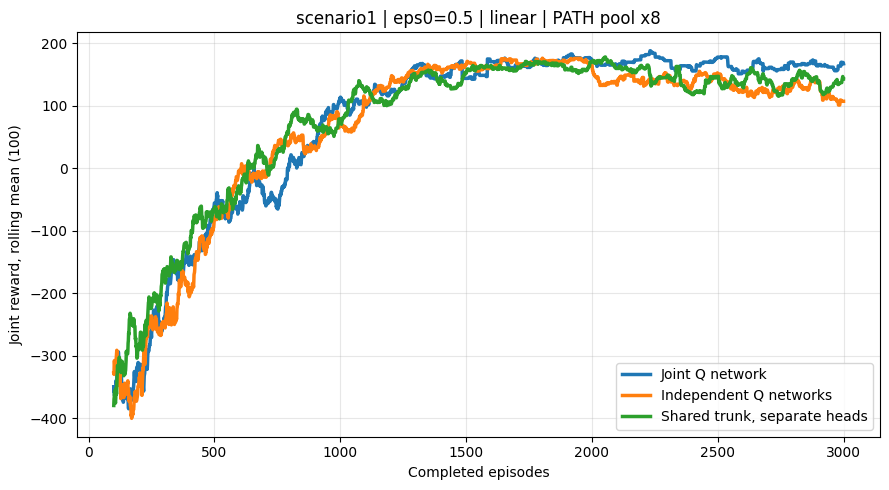

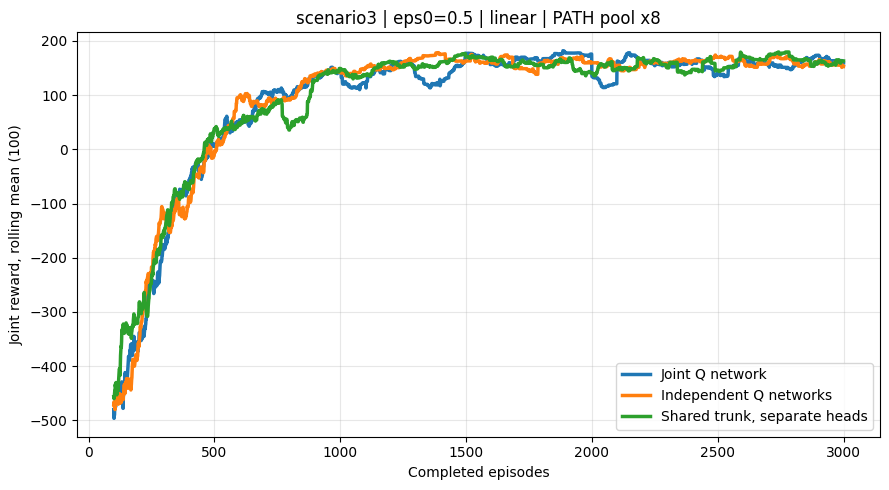

In [7]:
import matplotlib.pyplot as plt
import numpy as np


def rolling_mean(values, window=100):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return values
    window = max(1, min(int(window), values.size))
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(values, kernel, mode="valid")


ROLLING_WINDOW = 100
COLORS = dict(zip(
    [variant["label"] for variant in BASE_RUN_VARIANTS],
    plt.rcParams["axes.prop_cycle"].by_key()["color"],
))

for scenario_key in SCENARIOS:
    fig, ax = plt.subplots(figsize=(9, 5))
    for base_variant in BASE_RUN_VARIANTS:
        curves = []
        curve_xs = []
        for variant in RUN_VARIANTS:
            if variant["base_label"] != base_variant["label"]:
                continue
            stats = results[scenario_key][variant["label"]]
            rewards = stats["rewards"]
            min_len = min(len(rewards[0]), len(rewards[1]))
            if min_len == 0:
                continue
            joint_reward = (
                np.asarray(rewards[0][:min_len], dtype=float)
                + np.asarray(rewards[1][:min_len], dtype=float)
            )
            smoothed = rolling_mean(joint_reward, window=ROLLING_WINDOW)
            x = np.arange(smoothed.size) + min(ROLLING_WINDOW, joint_reward.size)
            curves.append(smoothed)
            curve_xs.append(x)
            ax.plot(
                x,
                smoothed,
                color=COLORS[base_variant["label"]],
                alpha=0.25,
                linewidth=1.0,
            )
        if curves:
            min_curve_len = min(curve.size for curve in curves)
            mean_curve = np.vstack([curve[:min_curve_len] for curve in curves]).mean(axis=0)
            mean_x = curve_xs[0][:min_curve_len]
            ax.plot(
                mean_x,
                mean_curve,
                color=COLORS[base_variant["label"]],
                linewidth=2.5,
                label=CASE_LABELS[base_variant["label"]],
            )
    ax.set_title(
        f"{scenario_key} | eps0={ROBUST_EPSILON_START:g} | "
        f"{EPSILON_SCHEDULE} | PATH pool x{BASE_HP['sre_solver_workers']}"
    )
    ax.set_xlabel("Completed episodes")
    ax.set_ylabel(f"Joint reward, rolling mean ({ROLLING_WINDOW})")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.savefig(OUTPUT_ROOT / f"reward_curves_{scenario_key}.png")
    plt.show()
